# **Занятие 5. Классификация изображений**

https://vk.com/lambda_brain

Классификация изображений -- это уже полноценная задача реального мира. Самое приятное здесь в том, что нету качественного алгоритмического отличия классификации изображений от классификации других наборов данных. Нейронные сети работают таким магическим образом, что мы просто подаём им на вход наборы "байтов", и не важно, что это -- абстрактные значения функций или пикселы изображений, они все анализируются нейросетью по единой схеме.

Мы познакомимся с основными принципами классификации изображений в PyTorch, а также изучим смежные вопросы, связанные с загрузкой объёмных датасетов с изображениями в программу и их удобной визуализацией.


# MNIST



---


В качестве первого примера воспользуемся распространённым датасетом изображений **MNIST**, на котором создано наверное максимальное количество обучающих уроков по нейронным сетям.

MNIST подготовлен **Яном ЛеКуном** -- ведущим мировым специалистом по нейронным сетям, и представляет собой датасет для обучения распознаванию рукописных цифр. Обучающая выборка содержит 60,000 изображений, и тестовая -- 10,000. Каждое изображение чёрно-белое размером 28x28 пикселов.

Импортируем нужные модули:


In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.datasets as dsets
import torchvision.transforms as transforms


Задаём гипер-параметры:

In [ ]:
input_size = 28 * 28  # Размер изображения в точках
hidden_size = 500  # Количество нейронов в скрытом слое
num_classes = 10  # Количество распознающихся классов (10 цифр)
n_epochs = 2  # Количество эпох
batch_size = 4  # Размер мини-пакета входных данных
lr = 0.01  # Скорость обучения

Большое количество готовых датасетов и различные удобные методы их загрузки и обработки собраны в модуле torchvision. Имеется в нём конечно и MNIST.

В конструкторе датасета MNIST указывается, как правило, каталог root, где будет локально размещён соответствующий датасет, download -- необходимость скачивания датасета для его локального использования, train -- признак, является ли данный датасет обучающим или тестовым, и трансформация transform, которую надо выполнить над данным датасетом. Последняя фича весьма полезна, потому что исходные изображения нередко требуется предварительно обрабатывать под конкретный формат их дальнейшего анализа. В нашем случае просто укажем стандартную трансформацию преобразования входных данных в тензоры.

Убедимся, что размеры датасета совпадают с официально объявленными.


In [ ]:
import torchvision.transforms as transforms

mnist_trainset = dsets.MNIST(
    root="./data", train=True, download=True, transform=transforms.ToTensor()
)
mnist_testset = dsets.MNIST(
    root="./data", train=False, download=True, transform=transforms.ToTensor()
)
print(len(mnist_trainset))
print(len(mnist_testset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 445kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.8MB/s]

60000
10000


Так как наш датасет большой по размеру, обрабатывать его надо небольшими порциями, мини-пакетами, как рассказывалось во втором занятии -- с помощью загрузчиков данных DataLoader.

In [ ]:
train_loader = torch.utils.data.DataLoader(
    dataset=mnist_trainset, batch_size=batch_size, shuffle=True
)  # загрузчик обучающих данных
test_loader = torch.utils.data.DataLoader(
    dataset=mnist_testset, batch_size=batch_size, shuffle=False
)  # загрузчик тестовых данных

Добавим наш стандартный шаг обучения.

In [ ]:
# импортируем нужные библиотеки
import torch
import numpy as np  # всегда пригодится :)
from torch.nn import Linear, Sigmoid

# инициализируем девайс
device = "cuda" if torch.cuda.is_available() else "cpu"


# добавляем типовую функцию "шаг обучения"
def make_train_step(model, loss_fn, optimizer):
    def train_step(x, y):
        model.train()
        yhat = model(x)
        loss = loss_fn(yhat, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        return loss.item()

    return train_step

Структура нашей модели будет представлять собой двуслойную нейронную сеть -- она ничем не отличается от модели, применявшейся в прошлом занятии при анализе абстрактного датасета (линейный вход + ReLU + линейный выход).

Воспользуемся лоссом CrossEntropyLoss() и методом оптимизации Adam.

Обратите внимание, что мы задаём уже не тысячи, а **всего две эпохи** -- процесс обучения на таком довольно объёмном датасете потребует уже прилично времени (несколько минут на одну эпоху).

Единственное дополнение -- мы применяем метод reshape(-1, 28 * 28), чтобы изменить входной трёхмерный формат изображения 1x28x28 (глубина цветности x размеры) на нужный нам одномерный вектор длиной 784 значения. Параметр -1 означает, что преобразование выполняется в одномерный результат.


In [ ]:
from torch import optim, nn

model = torch.nn.Sequential(
    nn.Linear(input_size, hidden_size), nn.ReLU(), nn.Linear(hidden_size, num_classes)
)
model.to(device)

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

train_step = make_train_step(model, loss_fn, optimizer)

for epoch in range(n_epochs):
    for images, labels in train_loader:
        images = images.reshape(-1, 28 * 28).to(device)
        images = images.to(device)
        labels = labels.to(device)
        loss = train_step(images, labels)
    print(epoch)

print(model.state_dict())
print(loss)

0
1
OrderedDict({'0.weight': tensor([[-0.0324, -0.0121, -0.0341,  ...,  0.0342, -0.0071, -0.0002],
        [-0.0216,  0.0144, -0.0081,  ..., -0.0132,  0.0318,  0.0305],
        [ 0.0013, -0.0065,  0.0005,  ...,  0.0213, -0.0247,  0.0072],
        ...,
        [-0.0233,  0.0021, -0.0083,  ..., -0.0187,  0.0296,  0.0348],
        [-0.0280,  0.0240,  0.0254,  ...,  0.0015,  0.0162, -0.0195],
        [-0.0050, -0.0281, -0.0084,  ...,  0.0193,  0.0049, -0.0354]],
       device='cuda:0'), '0.bias': tensor([-2.5923e-01, -6.3820e-02, -3.1927e-01, -2.6903e+00, -3.4429e-01,
        -7.2962e-02, -1.4114e-01, -5.4478e-02,  3.3819e-01, -2.1915e-01,
        -3.4315e-02, -2.6614e-02, -1.6523e+00, -5.8491e-02, -1.0537e-01,
        -5.5110e-02, -6.4167e-02, -6.0508e-01, -5.3131e-01, -1.0820e-01,
        -3.5333e-01, -6.2836e-02, -1.1473e-01, -5.0776e-02, -7.5154e-02,
        -1.0521e+00, -5.5802e-02, -3.0550e-02, -5.7462e-02, -5.4914e-01,
        -4.1457e-02, -3.8726e-02, -3.7321e-01, -4.2677e-02, -1.1

Теперь проверим, с какой точностью наша модель проверит 10,000 тестовых изображений:

In [ ]:
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.reshape(-1, 28 * 28).to(device)
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print("Точность: {} %".format(100 * correct / total))

Точность: 93.06 %


Около 90% -- это очень хороший результат для тренировки всего в течение пяти минут за две эпохи. Обратите внимание, что обученная модель время на распознавание даже такого приличного по объёму датасета уже практически не тратит.


---



Вычисление, конечно, может занимать не минуты, а часы, сутки, недели и месяцы работы. Чтобы продолжить работу с нашей обученной моделью уже в прикладных задачах, нам надо прежде всего её сохранить в файле (в PyTorch принято, что расширение файла с полностью сохранённой моделью -- .pt).


In [ ]:
torch.save(model, "mnist_full.pt")

Сохранение выполняется в виртуальной машине гугла, где мы загрузили датасет MNIST. Загрузка модели выполняется так же просто:

In [10]:
model = torch.load("mnist_full.pt", weights_only=False)
model.eval()

Sequential(
  (0): Linear(in_features=784, out_features=500, bias=True)
  (1): ReLU()
  (2): Linear(in_features=500, out_features=10, bias=True)
)

После загрузки модели надо обязательно выполнить её метод **eval()** -- это означает, что мы будем пользоваться моделью в режиме её эксплуатации, а не в режимах обучения или каких-то других.

##**Задание**

Попробуйте повысить точность нашей модели:

* увеличьте количество эпох;
* увеличьте количество нейронов;
* добавьте новые скрытые слои;
* измените размер мини-пакета.


---

* При желании придумайте, как визуализировать работу модели на тестовых данных (показывать изображения и соответствующий им распознанный класс).





In [ ]:
input_size = 28 * 28
hidden_size = 1024
num_classes = 10
n_epochs = 5
batch_size = 64
lr = 0.001

model = nn.Sequential(
    nn.Linear(input_size, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, 512),
    nn.ReLU(),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Linear(256, num_classes),
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.reshape(-1, input_size).to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.reshape(-1, input_size).to(device)
            labels = labels.to(device)

            outputs = model(images)
            predicted = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(
        f"Эпоха {epoch + 1}/{n_epochs}, loss: {running_loss / len(train_loader):.4f}, точность: {accuracy:.2f}%"
    )

Эпоха 1/5, loss: 0.2429, точность: 95.98%
Эпоха 2/5, loss: 0.1370, точность: 97.41%
Эпоха 3/5, loss: 0.1084, точность: 97.43%
Эпоха 4/5, loss: 0.0928, точность: 97.21%
Эпоха 5/5, loss: 0.0832, точность: 97.42%


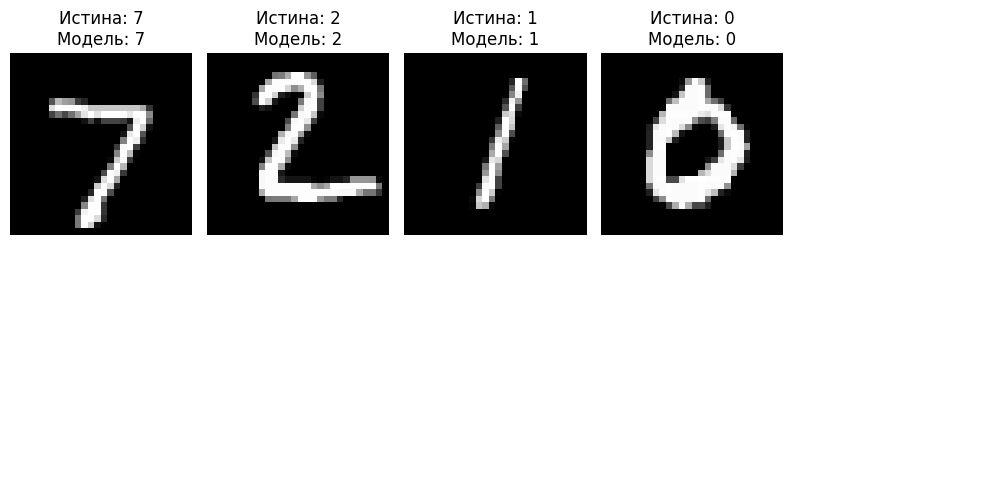

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(iter(test_loader))

images_device = images.reshape(-1, 28 * 28).to(device)

with torch.no_grad():
    predictions = model(images_device).argmax(dim=1).cpu()

n = min(len(images), 10)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    if i < n:
        ax.imshow(images[i].squeeze(), cmap="gray")
        ax.set_title(f"Истина: {labels[i].item()}\nМодель: {predictions[i].item()}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Далее мы рассмотрим работу с более сложным датасетом изображений (котики и пёсики), которому потребуется предварительная обработка.